In [ ]:
!pip install pillow

In [ ]:
#core libraries
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from PIL import Image
import pandas as pd

In [ ]:
#Sklearn
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

In [ ]:
#keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.preprocessing import image as keras_image


In [ ]:
print(f'TensorFlow version : {tf.__version__}')
print(f'Keras version      : {keras.__version__}')
print(f'GPU available      : {tf.config.list_physical_devices("GPU")}')

TensorFlow version : 2.20.0
Keras version      : 3.13.2
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

In [ ]:
train_dir=Path('/content/drive/MyDrive/Traffic_Sign/Train')
test_dir=Path('/content/drive/MyDrive/Traffic_Sign/Test')

In [ ]:
class_names=sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
num_classes=len(class_names)
print(f'Classes({num_classes}):{class_names}')

Classes(4):['Caution', 'Instructions', 'No Passing', 'OverSpeed']


In [ ]:
corrupted_images=[]
# Iterate through each class folder
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    for filename in os.listdir(class_path):
        image_path = os.path.join(class_path, filename)

        try:
            # Try opening, loading, and verifying the image
            with Image.open(image_path) as img:
                img.verify()  # checks if image is broken first
                img.load()    # then loads image data

        except (IOError, SyntaxError, Image.UnidentifiedImageError, AttributeError):
            # If corrupted or unidentifiable → remove it
            corrupted_images.append(image_path)
            os.remove(image_path)
            print(f"Removed corrupted image: {image_path}")

# Final report
print("\nTotal corrupted images removed:", len(corrupted_images))

Removed corrupted image: /content/drive/MyDrive/Traffic_Sign/Train/Instructions/00035_00001_00012.png
Removed corrupted image: /content/drive/MyDrive/Traffic_Sign/Train/Instructions/00033_00022_00001.png
Removed corrupted image: /content/drive/MyDrive/Traffic_Sign/Train/Instructions/00035_00033_00015.png
Removed corrupted image: /content/drive/MyDrive/Traffic_Sign/Train/Instructions/00034_00008_00025.png
Removed corrupted image: /content/drive/MyDrive/Traffic_Sign/Train/Instructions/00035_00015_00025.png
Removed corrupted image: /content/drive/MyDrive/Traffic_Sign/Train/Instructions/00035_00017_00006.png
Removed corrupted image: /content/drive/MyDrive/Traffic_Sign/Train/Instructions/00034_00000_00005.png
Removed corrupted image: /content/drive/MyDrive/Traffic_Sign/Train/Instructions/00033_00018_00027.png
Removed corrupted image: /content/drive/MyDrive/Traffic_Sign/Train/Instructions/00033_00006_00017.png
Removed corrupted image: /content/drive/MyDrive/Traffic_Sign/Train/Instructions/00

KeyboardInterrupt: 

Image Counts and Class Distrirbution

In [ ]:
def count_images(directory: Path) -> dict:
    """Return {class_name: count} for a split directory."""
    return {cls: len(list((directory / cls).glob('*.*'))) for cls in class_names}

train_counts = count_images(train_dir)
test_counts  = count_images(test_dir)
total_train  = sum(train_counts.values())
total_test   = sum(test_counts.values())

print(f'Total train images : {total_train}')
print(f'Total test  images : {total_test}')
print(f'Per-Class (Train)  : {train_counts}')

Total train images : 15888
Total test  images : 0
Per-Class (Train)  : {'Caution': 2429, 'Instructions': 2841, 'No Passing': 5369, 'OverSpeed': 5249}


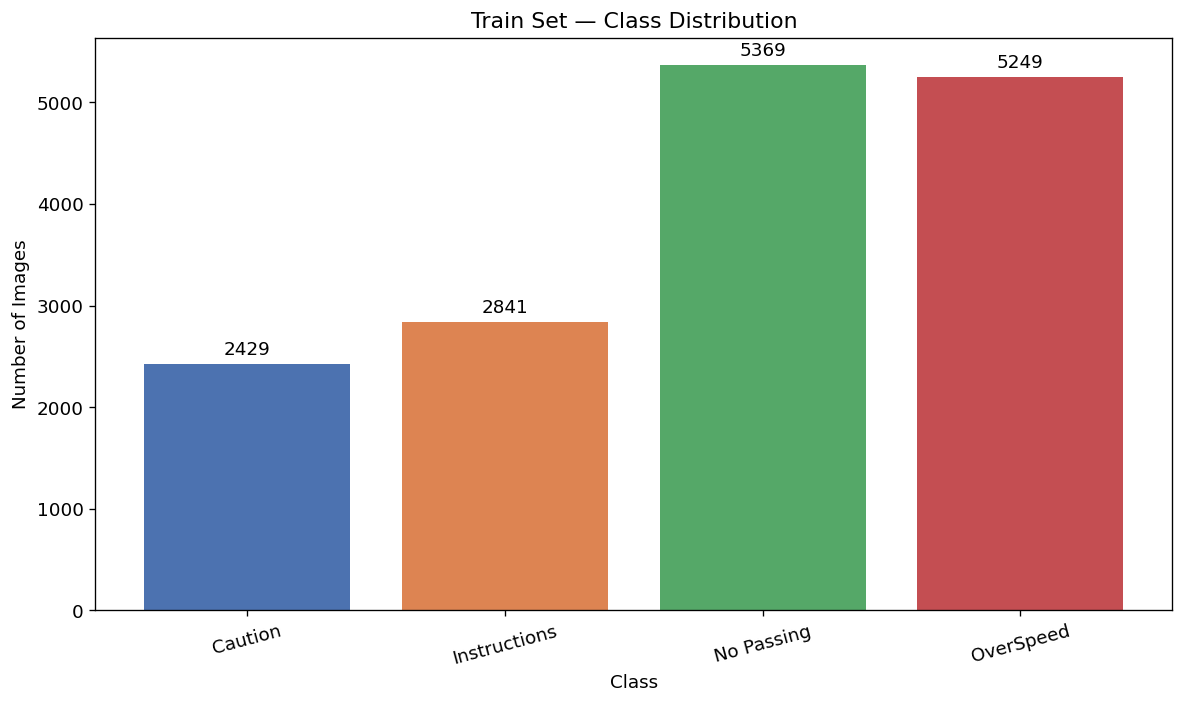

In [ ]:
# Class distribution bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(train_counts.keys(), train_counts.values(),
              color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
ax.bar_label(bars, padding=3)
ax.set_title('Train Set — Class Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Number of Images')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

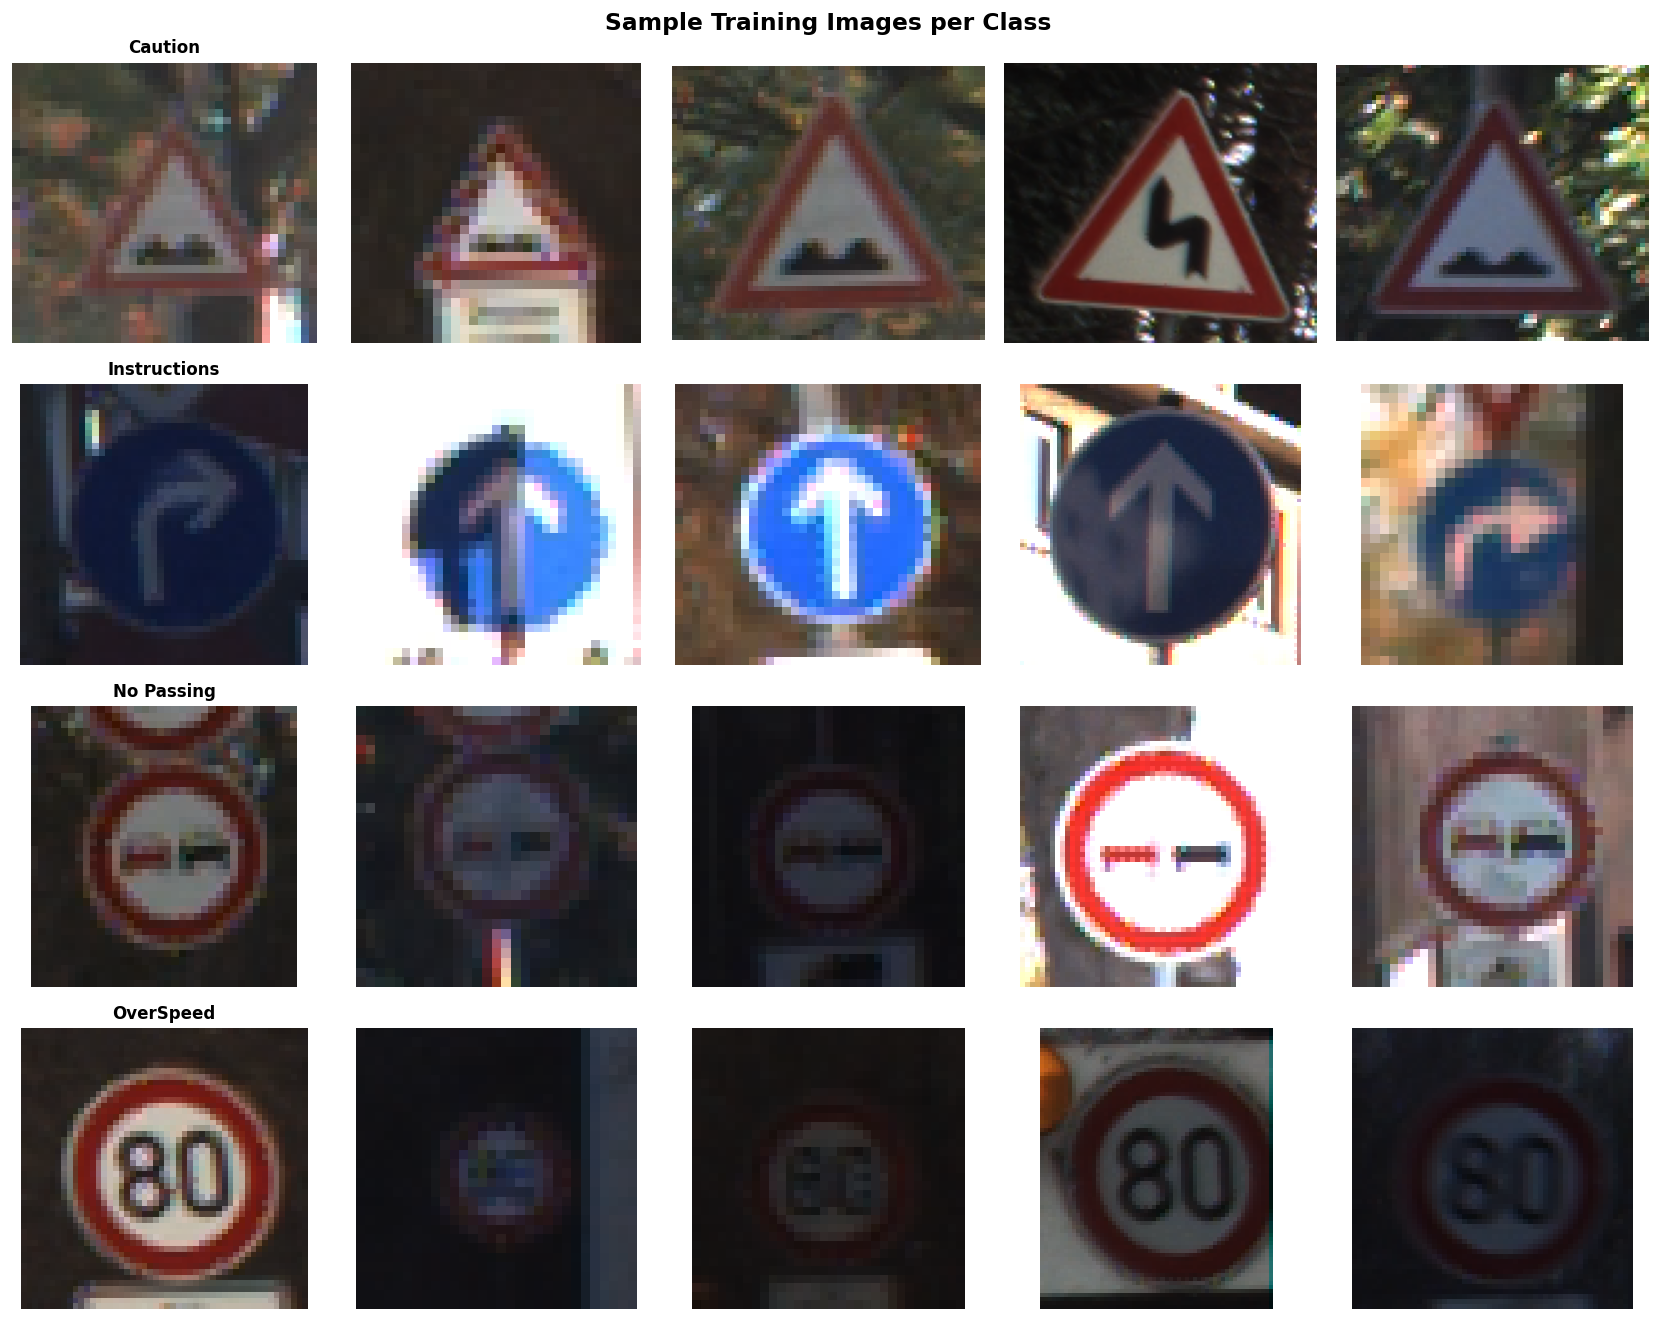

In [ ]:
# Sample images per class
fig, axes = plt.subplots(num_classes, 5, figsize=(14, num_classes * 2.8))
fig.suptitle('Sample Training Images per Class', fontsize=14, fontweight='bold')
for row, cls in enumerate(class_names):
    imgs = list((train_dir / cls).glob('*.*'))[:5]
    for col, img_path in enumerate(imgs):
        axes[row, col].imshow(mpimg.imread(img_path))
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(cls, fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

Data Preprocessing Configuration

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
#  Hyperparameters
IMG_SIZE   = (64, 64)
BATCH_SIZE = 32
VAL_SPLIT  = 0.2

#  Class weights
all_labels = []
for cls_idx, cls in enumerate(class_names):
    all_labels.extend([cls_idx] * train_counts[cls])
all_labels = np.array(all_labels)

class_weight_dict = dict(enumerate(
    compute_class_weight('balanced', classes=np.arange(num_classes), y=all_labels)
))
print('Class weights:', class_weight_dict)

Class weights: {0: np.float64(1.6352408398517908), 1: np.float64(1.3980992608236535), 2: np.float64(0.7398025703110449), 3: np.float64(0.756715564869499)}


In [ ]:
# ── Data generators
train_datagen = ImageDataGenerator(
    rescale          = 1./255,
    validation_split = VAL_SPLIT,
    rotation_range   = 10,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    zoom_range       = 0.1,
    fill_mode        = 'nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=VAL_SPLIT)

flow_kwargs = dict(
    directory  = str(train_dir),
    target_size= IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    classes    = class_names,
    seed       = SEED
)
train_gen = train_datagen.flow_from_directory(subset='training',   **flow_kwargs)
val_gen   = val_datagen.flow_from_directory(  subset='validation', **flow_kwargs)

print(f'Train batches: {len(train_gen)} | Val batches: {len(val_gen)}')

Found 12713 images belonging to 4 classes.
Found 3175 images belonging to 4 classes.
Train batches: 398 | Val batches: 100


In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    directory  = str(test_dir),
    target_size= IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    classes    = class_names,
    shuffle    = False,
    seed       = SEED
)
print(f'Test batches : {len(test_gen)}')

Found 0 images belonging to 4 classes.
Test batches : 0


Augumented Image Visualisation

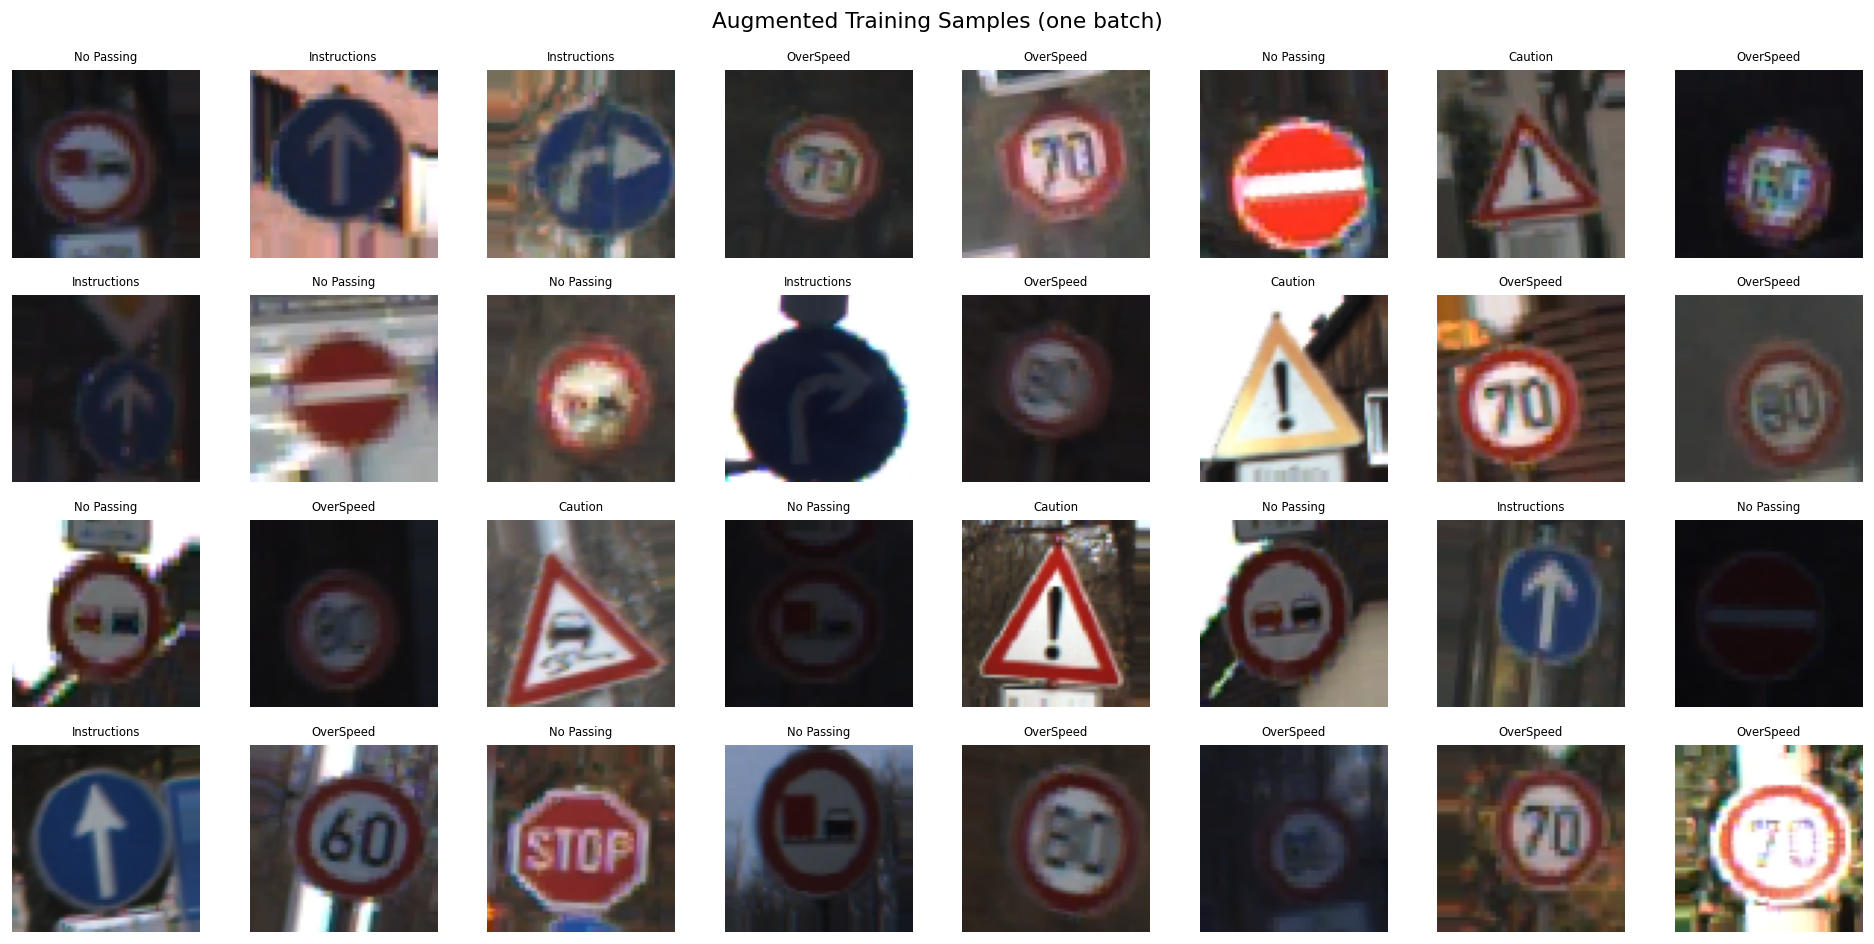

In [ ]:
batch_imgs, batch_labels = next(train_gen)
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle('Augmented Training Samples (one batch)', fontsize=13)
for i, ax in enumerate(axes.ravel()):
    if i < len(batch_imgs):
        ax.imshow(np.clip(batch_imgs[i], 0, 1))
        ax.set_title(class_names[np.argmax(batch_labels[i])], fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()

Baseline CNN Mode(Task1)

In [ ]:
def plot_history(history, title='Training History'):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title, fontsize=13)
    axes[0].plot(history.history['accuracy'],     label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Val')
    axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(True)
    axes[1].plot(history.history['loss'],     label='Train')
    axes[1].plot(history.history['val_loss'], label='Val')
    axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:

def evaluate_model(model, generator, class_names, title='Evaluation'):
    generator.reset()
    y_pred_proba = model.predict(generator, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = generator.classes

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred,    average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred,        average='weighted', zero_division=0)

    print(f'\n=== {title} ===')
    print(f'Accuracy  : {acc:.4f}')
    print(f'Precision : {prec:.4f}')
    print(f'Recall    : {rec:.4f}')
    print(f'F1-Score  : {f1:.4f}')
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {title}')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(f'cm_{title.lower().replace(" ", "_")}.png', bbox_inches='tight')
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

In [ ]:
def plot_inference(model, generator, class_names, n=10, title='Inference'):
    generator.reset()
    imgs, labels = next(generator)
    preds    = model.predict(imgs[:n], verbose=0)
    pred_cls = np.argmax(preds, axis=1)
    true_cls = np.argmax(labels[:n], axis=1)
    cols = 5; rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    fig.suptitle(title, fontsize=13)
    for i, ax in enumerate(axes.ravel()):
        if i < n:
            ax.imshow(np.clip(imgs[i], 0, 1))
            color = 'green' if pred_cls[i] == true_cls[i] else 'red'
            ax.set_title(
                f'True: {class_names[true_cls[i]]}\nPred: {class_names[pred_cls[i]]}',
                fontsize=8, color=color)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

Model architecture

In [ ]:
def build_baseline_model(input_shape=(64, 64, 3), num_classes=4):
    model = models.Sequential(name='Baseline_CNN')

    # Conv Block 1
    model.add(layers.Conv2D(32, (3, 3), activation='relu',
                            padding='same', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2, 2)))

    # Conv Block 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    # Conv Block 3
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    # 3 Fully Connected layers
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))   # FCN 1
    model.add(layers.Dense(128, activation='relu'))   # FCN 2
    model.add(layers.Dense(64,  activation='relu'))   # FCN 3
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

baseline_model = build_baseline_model(input_shape=(*IMG_SIZE, 3), num_classes=num_classes)
baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,232,068 (8.51 MB)

 Trainable params: 2,232,068 (8.51 MB)

 Non-trainable params: 0 (0.00 B)

Compile and Train Baseline Model

In [ ]:
baseline_model.compile(
    optimizer = Adam(learning_rate=1e-4),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

callbacks_base = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, verbose=1, min_lr=1e-7)
]

In [ ]:
t0 = time.time()
history_base = baseline_model.fit(
    train_gen,
    epochs          = 50,
    validation_data = val_gen,
    callbacks       = callbacks_base,
    class_weight    = class_weight_dict,
    verbose         = 1
)
baseline_train_time = time.time() - t0
print(f'\nBaseline training time: {baseline_train_time:.1f} s')

Epoch 1/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 77s 181ms/step - accuracy: 0.7337 - loss: 0.5921 - val_accuracy: 0.6589 - val_loss: 2.6390 - learning_rate: 1.0000e-04
Epoch 2/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 69s 172ms/step - accuracy: 0.9603 - loss: 0.1288 - val_accuracy: 0.7427 - val_loss: 2.9022 - learning_rate: 1.0000e-04
Epoch 3/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 70s 177ms/step - accuracy: 0.9801 - loss: 0.0642 - val_accuracy: 0.7241 - val_loss: 2.9394 - learning_rate: 1.0000e-04
Epoch 4/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 68s 171ms/step - accuracy: 0.9873 - loss: 0.0382 - val_accuracy: 0.8107 - val_loss: 3.4330 - learning_rate: 1.0000e-04
Epoch 5/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 70s 177ms/step - accuracy: 0.9904 - loss: 0.0293 - val_accuracy: 0.8060 - val_loss: 3.6763 - learning_rate: 1.0000e-04
Epoch 6/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 71s 177ms/step - accuracy: 0.9926 - loss: 0.0222 - val_accuracy: 0.8164 - val_loss: 3.4765 - learning_rate: 1.0000e-04
Epoch 7/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 146

In [ ]:
baseline_train_time = time.time() - t0
print(f'\nBaseline training time: {baseline_train_time:.1f} s')


Baseline training time: 954.4 s


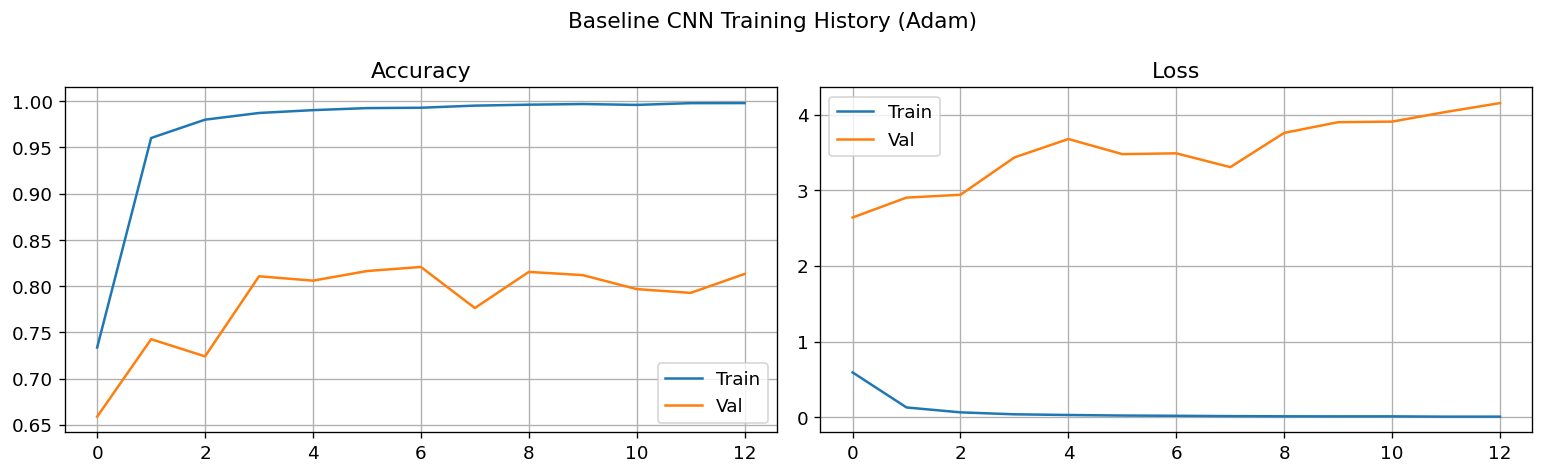


=== Baseline — Validation ===
Accuracy  : 0.2822
Precision : 0.2823
Recall    : 0.2822
F1-Score  : 0.2656
              precision    recall  f1-score   support

     Caution       0.16      0.36      0.22       484
Instructions       0.12      0.01      0.02       568
  No Passing       0.35      0.27      0.30      1072
   OverSpeed       0.35      0.41      0.38      1051

    accuracy                           0.28      3175
   macro avg       0.25      0.26      0.23      3175
weighted avg       0.28      0.28      0.27      3175



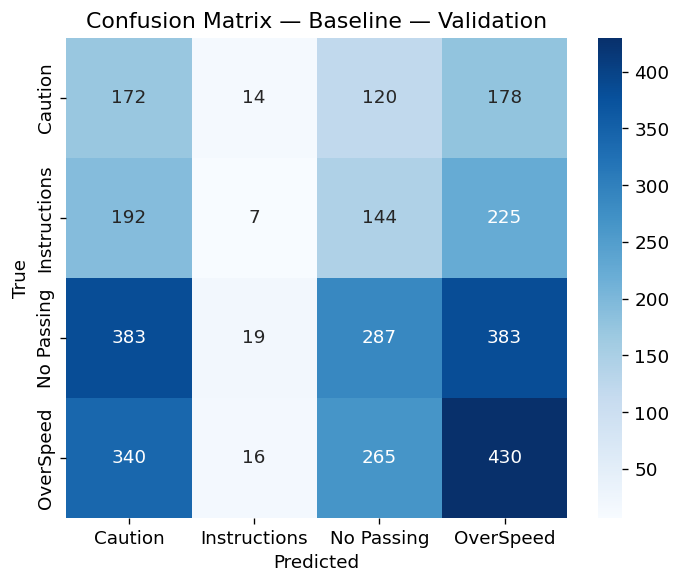

In [ ]:
plot_history(history_base, title='Baseline CNN Training History (Adam)')
metrics_base_val = evaluate_model(baseline_model, val_gen,
                                   class_names, title='Baseline — Validation')

Sample Inference

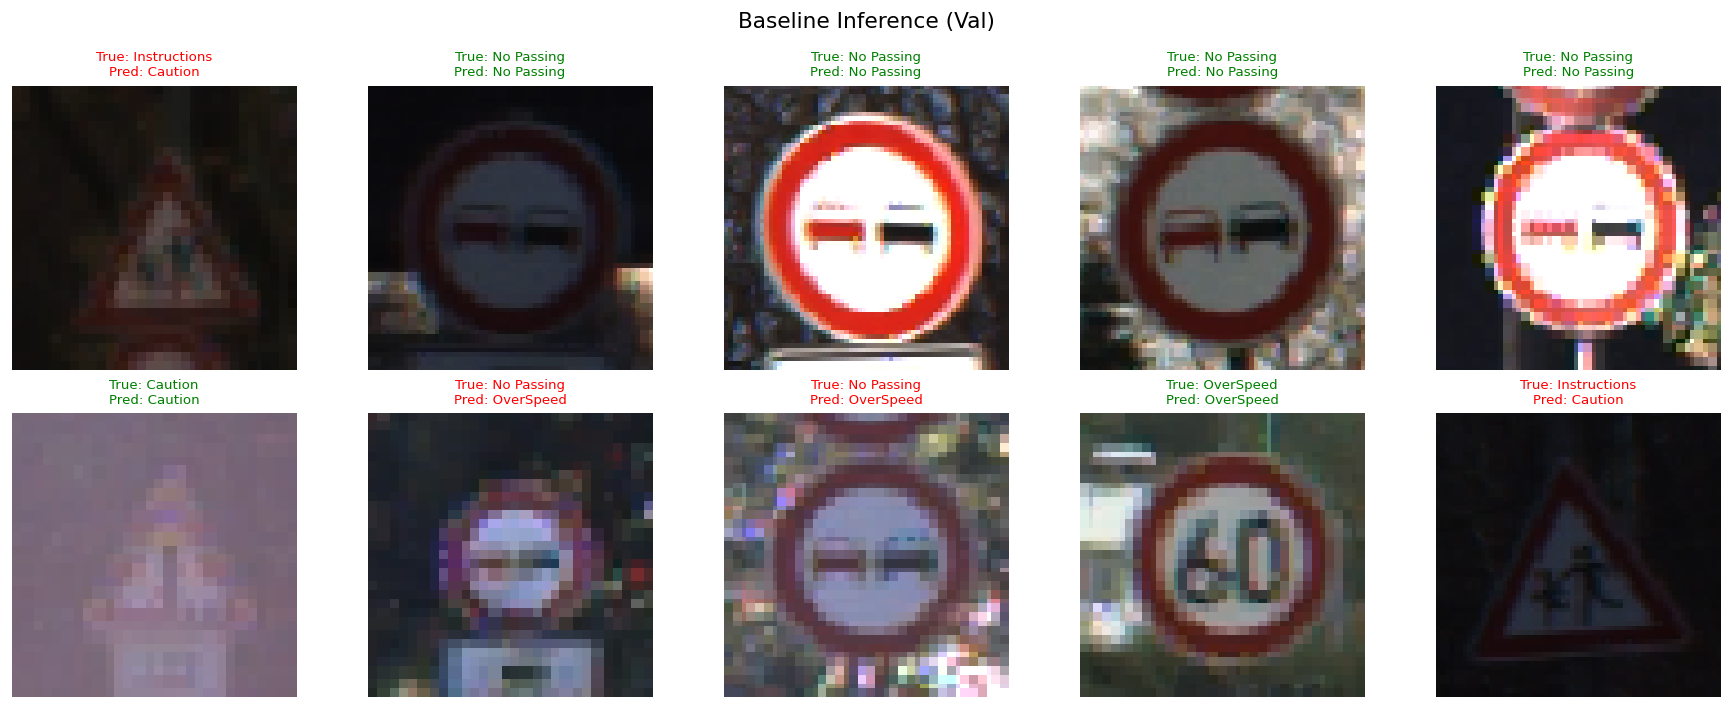

In [ ]:
plot_inference(baseline_model, val_gen, class_names, n=10, title='Baseline Inference (Val)')

 CNN with Regularisation

In [ ]:
def build_deeper_model(input_shape=(64, 64, 3), num_classes=4,
                       use_bn=True, use_dropout=True, dropout_rate=0.4):
    model = models.Sequential(name='Deeper_CNN')

    def conv_block(filters, first_layer=False):
        """Conv + optional BN + ReLU"""
        if first_layer:
            model.add(layers.Conv2D(filters, (3, 3), padding='same',
                                    kernel_regularizer=regularizers.l2(1e-4),
                                    input_shape=input_shape))
        else:
            model.add(layers.Conv2D(filters, (3, 3), padding='same',
                                    kernel_regularizer=regularizers.l2(1e-4)))
        if use_bn:
            model.add(layers.BatchNormalization())
        model.add(layers.Activation('relu'))

    # Block 1
    conv_block(32, first_layer=True)
    conv_block(32)
    model.add(layers.MaxPooling2D((2, 2)))
    if use_dropout: model.add(layers.Dropout(0.25))

    # Block 2
    conv_block(64)
    conv_block(64)
    model.add(layers.MaxPooling2D((2, 2)))
    if use_dropout: model.add(layers.Dropout(0.25))

    # Block 3
    conv_block(128)
    conv_block(128)
    model.add(layers.MaxPooling2D((2, 2)))
    if use_dropout: model.add(layers.Dropout(0.25))

    # Classifier head
    model.add(layers.Flatten())
    if use_dropout: model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4)))
    if use_dropout: model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)))
    if use_dropout: model.add(layers.Dropout(0.3))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

deeper_model = build_deeper_model(input_shape=(*IMG_SIZE, 3), num_classes=num_classes)
deeper_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 16, 16, 128)    │             

 Total params: 4,615,972 (17.61 MB)

 Trainable params: 4,615,076 (17.61 MB)

 Non-trainable params: 896 (3.50 KB)

Compile & Train Deeper Model (Adam)

In [ ]:
deeper_model.compile(
    optimizer = Adam(learning_rate=5e-4),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

callbacks_deep = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1, min_lr=1e-7)
]

t0 = time.time()
history_deep = deeper_model.fit(
    train_gen,
    epochs          = 50,
    validation_data = val_gen,
    callbacks       = callbacks_deep,
    class_weight    = class_weight_dict,
    verbose         = 1
)
deeper_train_time = time.time() - t0
print(f'\nDeeper CNN training time: {deeper_train_time:.1f} s')

Epoch 1/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 95s 201ms/step - accuracy: 0.7241 - loss: 0.8583 - val_accuracy: 0.4702 - val_loss: 2.4325 - learning_rate: 5.0000e-04
Epoch 2/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 70s 175ms/step - accuracy: 0.9552 - loss: 0.2709 - val_accuracy: 0.7748 - val_loss: 3.8546 - learning_rate: 5.0000e-04
Epoch 3/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 80s 171ms/step - accuracy: 0.9793 - loss: 0.2114 - val_accuracy: 0.7934 - val_loss: 3.7442 - learning_rate: 5.0000e-04
Epoch 4/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 68s 171ms/step - accuracy: 0.9819 - loss: 0.2007 - val_accuracy: 0.8202 - val_loss: 7.1417 - learning_rate: 5.0000e-04
Epoch 5/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 68s 171ms/step - accuracy: 0.9856 - loss: 0.1804 - val_accuracy: 0.7616 - val_loss: 5.8253 - learning_rate: 5.0000e-04
Epoch 6/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9891 - loss: 0.1670
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
398/398 ━━━━━━━━━━━━━━━━━━━━ 68s 171ms/st

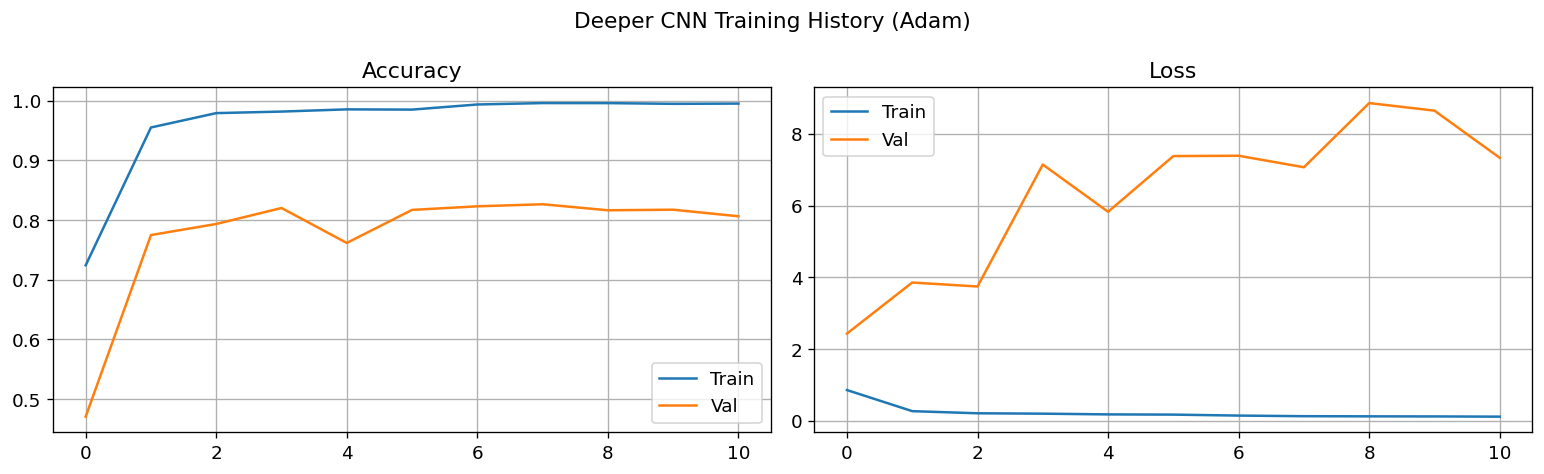


=== Deeper CNN (Adam) — Validation ===
Accuracy  : 0.2863
Precision : 0.2570
Recall    : 0.2863
F1-Score  : 0.2028
              precision    recall  f1-score   support

     Caution       0.15      0.22      0.18       484
Instructions       0.15      0.01      0.01       568
  No Passing       0.29      0.04      0.07      1072
   OverSpeed       0.33      0.72      0.45      1051

    accuracy                           0.29      3175
   macro avg       0.23      0.25      0.18      3175
weighted avg       0.26      0.29      0.20      3175



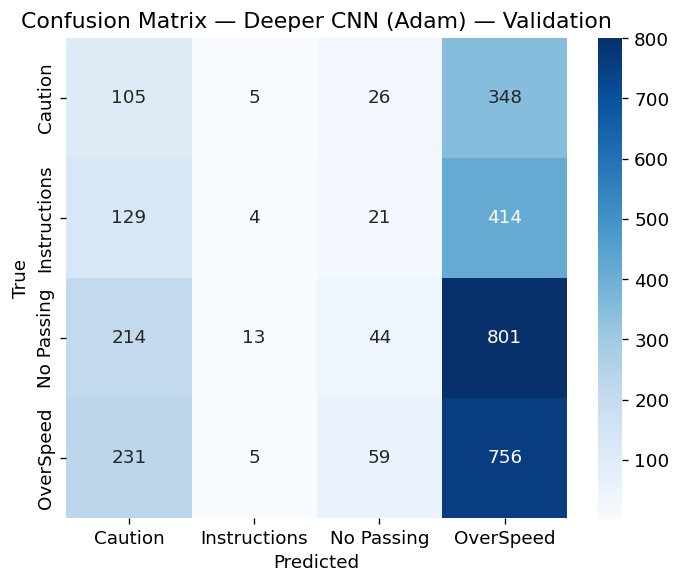

In [ ]:
plot_history(history_deep, title='Deeper CNN Training History (Adam)')
metrics_deep_val = evaluate_model(deeper_model, val_gen,
                                   class_names, title='Deeper CNN (Adam) — Validation')

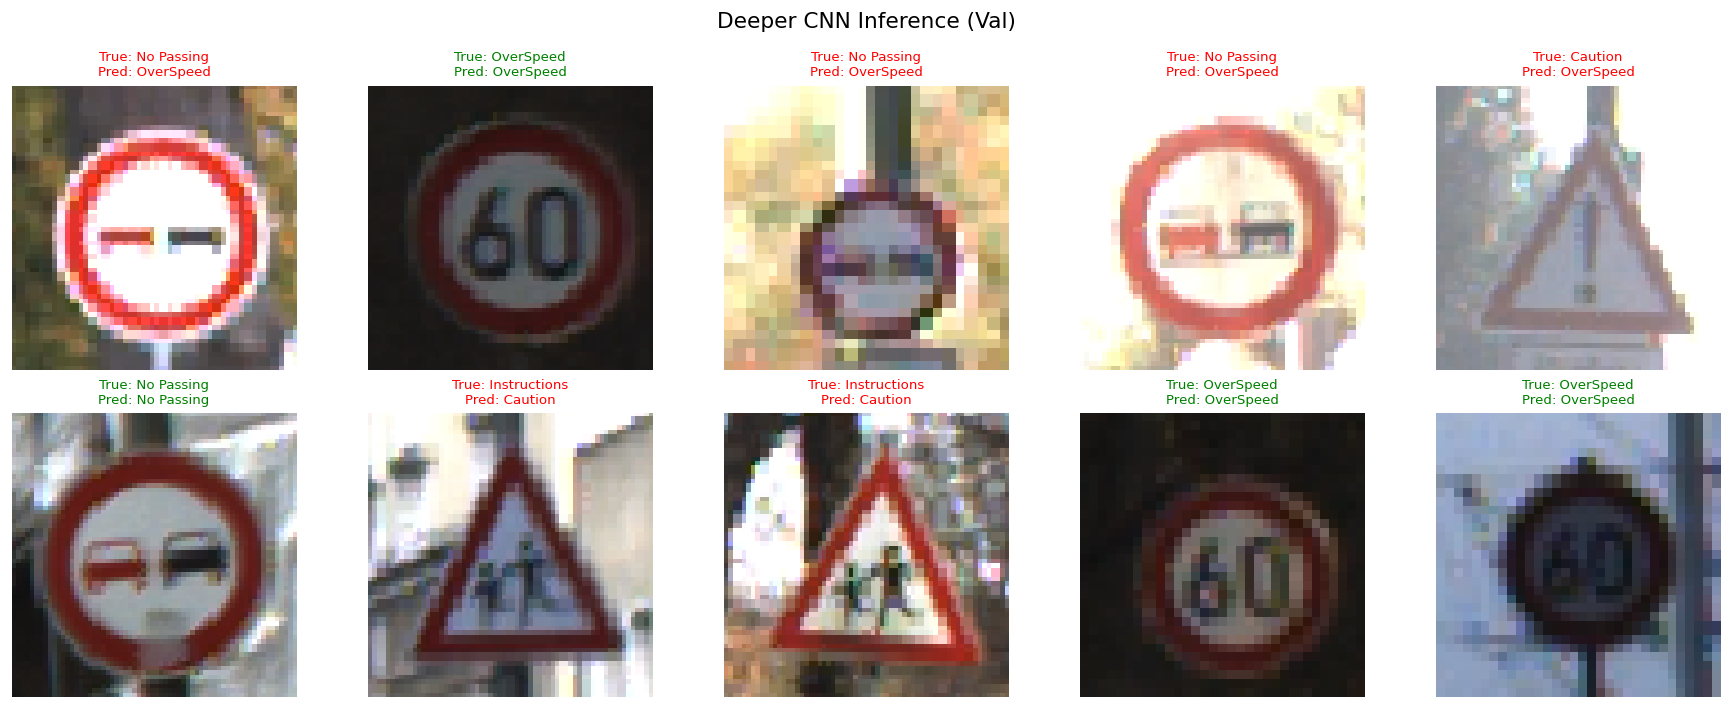

In [ ]:
plot_inference(deeper_model, val_gen, class_names, n=10, title='Deeper CNN Inference (Val)')

Basline vs Deeper Comparision

In [ ]:
comparison_df = pd.DataFrame({
    'Model'        : ['Baseline CNN', 'Deeper CNN (Adam)'],
    'Accuracy'     : [metrics_base_val['accuracy'],  metrics_deep_val['accuracy']],
    'Precision'    : [metrics_base_val['precision'], metrics_deep_val['precision']],
    'Recall'       : [metrics_base_val['recall'],    metrics_deep_val['recall']],
    'F1-Score'     : [metrics_base_val['f1'],        metrics_deep_val['f1']],
    'Train Time(s)': [baseline_train_time,           deeper_train_time]
})
print('\nModel Comparison:')
print(comparison_df.to_string(index=False))


Model Comparison:
            Model  Accuracy  Precision   Recall  F1-Score  Train Time(s)
     Baseline CNN  0.282205   0.282292 0.282205  0.265620     954.392891
Deeper CNN (Adam)  0.286299   0.257032 0.286299  0.202764     785.383069


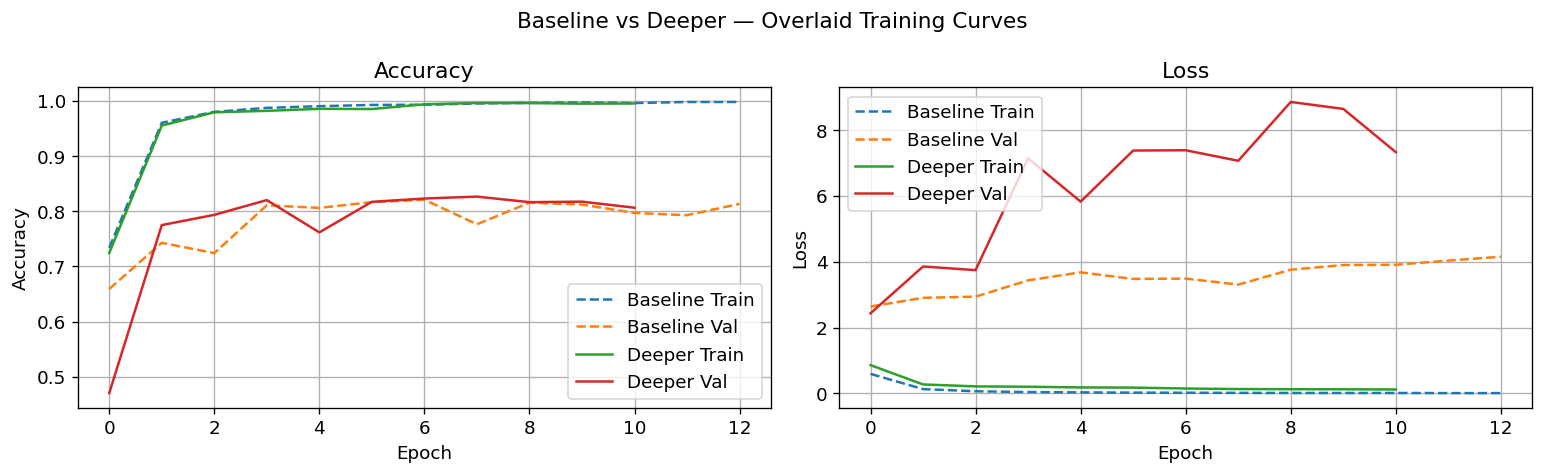

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Baseline vs Deeper — Overlaid Training Curves', fontsize=13)
for ax, (train_key, val_key), ylabel in zip(
    axes,
    [('accuracy', 'val_accuracy'), ('loss', 'val_loss')],
    ['Accuracy', 'Loss']
):
    ax.plot(history_base.history[train_key], ls='--', label='Baseline Train')
    ax.plot(history_base.history[val_key],   ls='--', label='Baseline Val')
    ax.plot(history_deep.history[train_key],           label='Deeper Train')
    ax.plot(history_deep.history[val_key],             label='Deeper Val')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.set_title(ylabel); ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()

Depper Model with SGD

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 100s 194ms/step - accuracy: 0.4570 - loss: 1.2436 - val_accuracy: 0.2652 - val_loss: 2.0076 - learning_rate: 0.0100
Epoch 2/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 69s 173ms/step - accuracy: 0.7613 - loss: 1.4130 - val_accuracy: 0.1764 - val_loss: 706.4586 - learning_rate: 0.0100
Epoch 3/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 66s 167ms/step - accuracy: 0.7052 - loss: 1.1076 - val_accuracy: 0.6939 - val_loss: 3.3899 - learning_rate: 0.0100
Epoch 4/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 65s 164ms/step - accuracy: 0.9350 - loss: 0.5939 - val_accuracy: 0.7628 - val_loss: 4.4393 - learning_rate: 0.0100
Epoch 5/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 65s 163ms/step - accuracy: 0.9684 - loss: 0.5039 - val_accuracy: 0.8161 - val_loss: 4.3581 - learning_rate: 0.0100
Epoch 6/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.9780 - loss: 0.4725
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
398/398 ━━━━━━━━━━━━━━━━━━━━ 64s 162ms/step - accuracy: 0.9

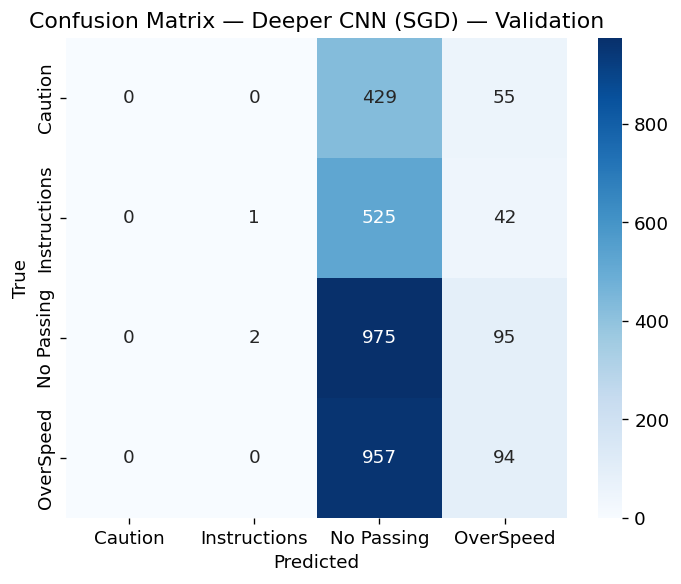

In [ ]:
deeper_sgd = build_deeper_model(input_shape=(*IMG_SIZE, 3), num_classes=num_classes)
deeper_sgd.compile(
    optimizer = SGD(learning_rate=1e-2, momentum=0.9, nesterov=True),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

t0 = time.time()
history_sgd = deeper_sgd.fit(
    train_gen,
    epochs          = 50,
    validation_data = val_gen,
    callbacks       = callbacks_deep,
    class_weight    = class_weight_dict,
    verbose         = 1
)
sgd_train_time = time.time() - t0
print(f'\nSGD training time: {sgd_train_time:.1f} s')

metrics_sgd = evaluate_model(deeper_sgd, val_gen,
                              class_names, title='Deeper CNN (SGD) — Validation')

Adam VS SDG

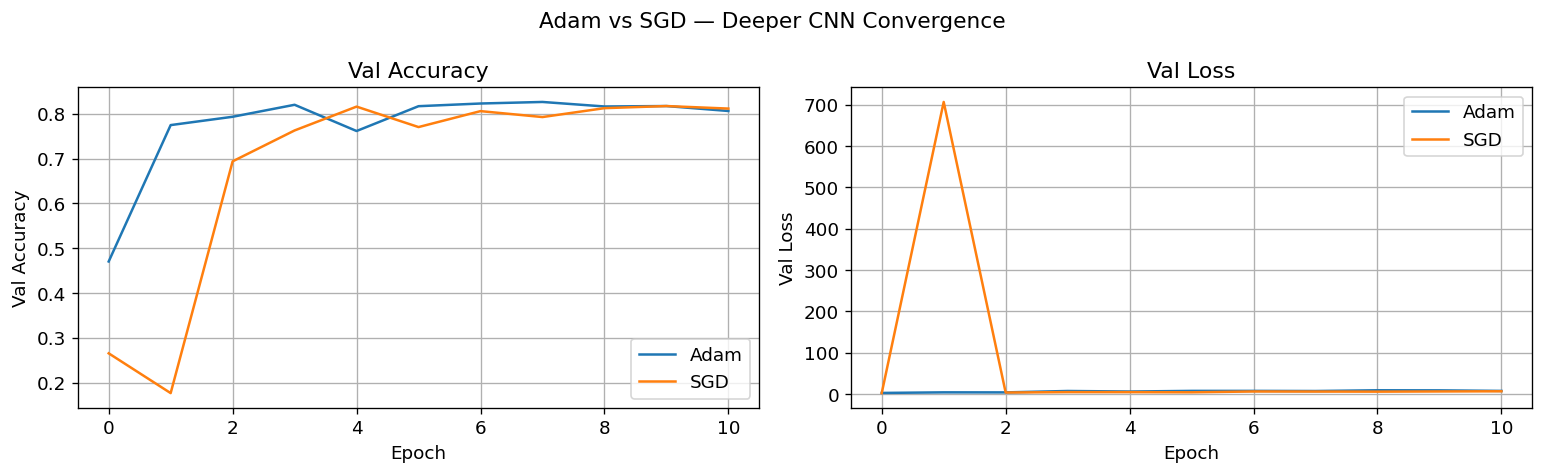

Adam F1: 0.2028  |  SGD F1: 0.2135


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Adam vs SGD — Deeper CNN Convergence', fontsize=13)
for ax, key, ylabel in zip(
    axes, ['val_accuracy', 'val_loss'], ['Val Accuracy', 'Val Loss']
):
    ax.plot(history_deep.history[key], label='Adam')
    ax.plot(history_sgd.history[key],  label='SGD')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.set_title(ylabel); ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig('adam_vs_sgd.png', bbox_inches='tight'); plt.show()
print(f"Adam F1: {metrics_deep_val['f1']:.4f}  |  SGD F1: {metrics_sgd['f1']:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 1.

=== No Dropout — Validation ===
Accuracy  : 0.2844
Precision : 0.2903
Recall    : 0.2844
F1-Score  : 0.2736
              precision    recall  f1-score   support

     Caution       0.16      0.34      0.22       484
Instructions       0.18      0.04      0.06       568
  No Passing       0.35      0.31      0.33      1072
   OverSpeed       0.35      0.37      0.36      1051

    accuracy                           0.28      3175
   macro avg       0.26      0.26      0.24      3175
weighted avg       0.29      0.28      0.27      3175



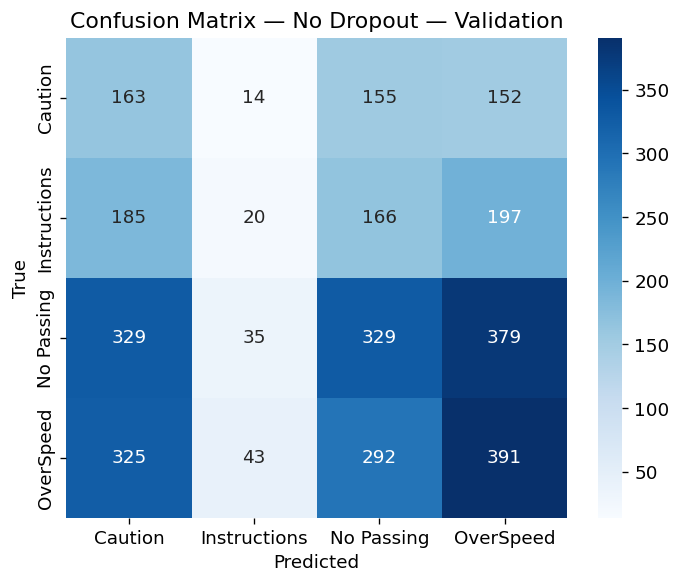

In [ ]:
# ABLATION: No Dropout
model_no_dropout = build_deeper_model(input_shape=(*IMG_SIZE, 3),
                                       num_classes=num_classes,
                                       use_dropout=False)
model_no_dropout.compile(
    optimizer = Adam(learning_rate=5e-4),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
history_no_drop = model_no_dropout.fit(
    train_gen,
    epochs          = 30,
    validation_data = val_gen,
    callbacks       = callbacks_deep,
    class_weight    = class_weight_dict,
    verbose         = 0
)
metrics_no_dropout = evaluate_model(model_no_dropout, val_gen,
                                     class_names, title='No Dropout — Validation')

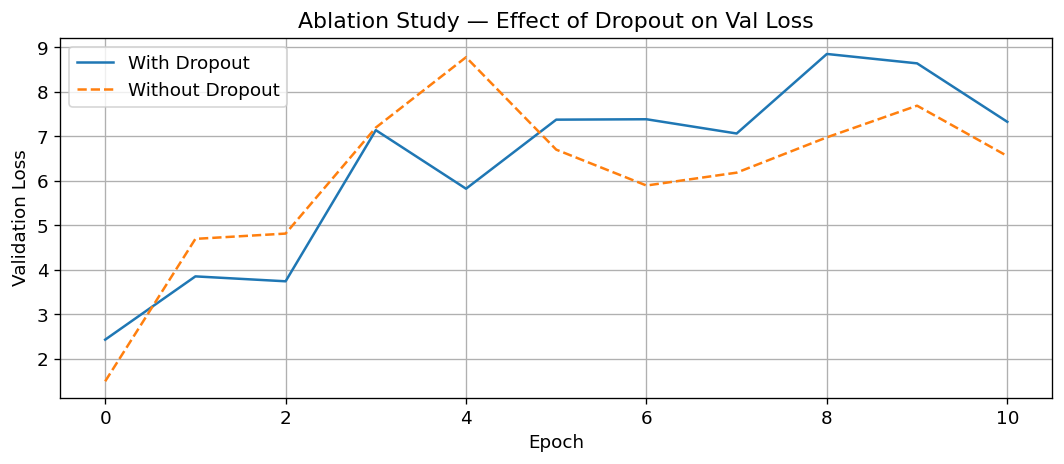

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history_deep.history['val_loss'],    label='With Dropout')
ax.plot(history_no_drop.history['val_loss'], label='Without Dropout', ls='--')
ax.set_title('Ablation Study — Effect of Dropout on Val Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation Loss')
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
print(f"With Dropout    F1: {metrics_deep_val['f1']:.4f}")
print(f"Without Dropout F1: {metrics_no_dropout['f1']:.4f}")

With Dropout    F1: 0.2028
Without Dropout F1: 0.2736


In [ ]:
print(f'Baseline CNN      : {baseline_train_time:.1f} s')
print(f'Deeper CNN (Adam) : {deeper_train_time:.1f} s')
print(f'Deeper CNN (SGD)  : {sgd_train_time:.1f} s')
gpus = tf.config.list_physical_devices('GPU')
print(f'Hardware          : {"GPU (T4)" if gpus else "CPU only"}')

Baseline CNN      : 954.4 s
Deeper CNN (Adam) : 785.4 s
Deeper CNN (SGD)  : 763.9 s
Hardware          : GPU (T4)


Part B

In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess


In [ ]:
IMG_SIZE_B = (224, 224)   # VGG16 requires 224×224

train_datagen_b = ImageDataGenerator(
    preprocessing_function = vgg_preprocess,
    validation_split       = VAL_SPLIT,
    rotation_range         = 15,
    width_shift_range      = 0.1,
    height_shift_range     = 0.1,
    zoom_range             = 0.15,
    fill_mode              = 'nearest'
)
val_datagen_b = ImageDataGenerator(
    preprocessing_function = vgg_preprocess,
    validation_split       = VAL_SPLIT
)

In [ ]:
flow_kwargs_b = dict(
    directory  = str(train_dir),
    target_size= IMG_SIZE_B,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    classes    = class_names,
    seed       = SEED
)
train_gen_b = train_datagen_b.flow_from_directory(subset='training',   **flow_kwargs_b)
val_gen_b   = val_datagen_b.flow_from_directory(  subset='validation', **flow_kwargs_b)

print(f'Part B Train batches : {len(train_gen_b)}')
print(f'Part B Val   batches : {len(val_gen_b)}')

Found 12713 images belonging to 4 classes.
Found 3175 images belonging to 4 classes.
Part B Train batches : 398
Part B Val   batches : 100


In [ ]:
base_model = VGG16(
    weights     = 'imagenet',
    include_top = False,
    input_shape = (*IMG_SIZE_B, 3)
)
base_model.trainable = False   # Phase 1: freeze all conv layers
print(f'VGG16 trainable layers (frozen): {sum(l.trainable for l in base_model.layers)}')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 trainable layers (frozen): 0


In [ ]:
inputs  = keras.Input(shape=(*IMG_SIZE_B, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)          # Better than Flatten for VGG
x       = layers.Dense(512, activation='relu',
                        kernel_regularizer=regularizers.l2(1e-4))(x)
x       = layers.Dropout(0.5)(x)
x       = layers.Dense(256, activation='relu',
                        kernel_regularizer=regularizers.l2(1e-4))(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

tl_model = keras.Model(inputs, outputs, name='VGG16_Transfer')
tl_model.summary()

Model: "VGG16_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,109,700 (57.64 MB)

 Trainable params: 395,012 (1.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
tl_model.compile(
    optimizer = Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

callbacks_tl = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1, min_lr=1e-7)
]

In [ ]:
t0 = time.time()
history_fe = tl_model.fit(
    train_gen_b,
    epochs          = 20,
    validation_data = val_gen_b,
    callbacks       = callbacks_tl,
    class_weight    = class_weight_dict,
    verbose         = 1
)
fe_train_time = time.time() - t0
print(f'\nFeature Extraction training time: {fe_train_time:.1f} s')

Epoch 1/20
  2/398 ━━━━━━━━━━━━━━━━━━━━ 1:06 167ms/step - accuracy: 0.2031 - loss: 3.3274 

UnknownError: Graph execution error:

Detected at node PyFunc defined at (most recent call last):
<stack traces unavailable>
Detected at node PyFunc defined at (most recent call last):
<stack traces unavailable>
2 root error(s) found.
  (0) UNKNOWN:  UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x7d74286f3ce0>
Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/ops/script_ops.py", line 269, in __call__
    ret = func(*args)
          ^^^^^^^^^^^

  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/autograph/impl/api.py", line 643, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^

  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/from_generator_op.py", line 198, in generator_py_func
    values = next(generator_state.get_iterator(iterator_id))
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

  File "/usr/local/lib/python3.12/dist-p

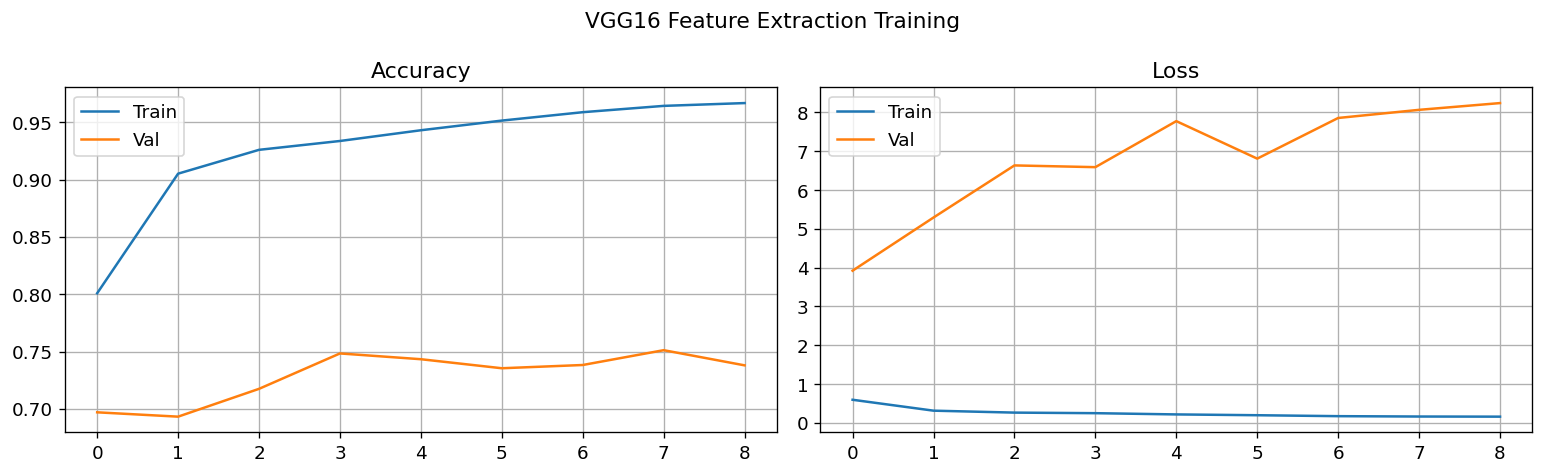

In [ ]:
plot_history(history_fe, title='VGG16 Feature Extraction Training')

In [ ]:
base_model.trainable = True
for layer in base_model.layers:
    layer.trainable = 'block5' in layer.name   # Only unfreeze last conv block

trainable = sum(l.trainable for l in base_model.layers)
print(f'Trainable VGG layers after unfreezing block5: {trainable}')

Trainable VGG layers after unfreezing block5: 4


In [ ]:
tl_model.compile(
    optimizer = Adam(learning_rate=1e-5),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

t0 = time.time()
history_ft = tl_model.fit(
    train_gen_b,
    epochs          = 20,
    validation_data = val_gen_b,
    callbacks       = callbacks_tl,
    class_weight    = class_weight_dict,
    verbose         = 1
)
ft_train_time = time.time() - t0
print(f'\nFine-Tuning training time: {ft_train_time:.1f} s')

Epoch 1/20
 68/398 ━━━━━━━━━━━━━━━━━━━━ 2:03:48 23s/step - accuracy: 0.1605 - loss: 3.8541

KeyboardInterrupt: 

In [ ]:
plot_history(history_ft, title='VGG16 Fine-Tuning Training')

Evaluation


In [ ]:
metrics_tl_val = evaluate_model(tl_model, val_gen_b,
                                 class_names, title='VGG16 Transfer Learning — Validation')

In [ ]:
def plot_vgg_inference(model, generator, class_names, n=10, title='VGG16 Inference'):
    """Show predictions using the VGG-preprocessed generator."""
    generator.reset()
    imgs, labels = next(generator)
    preds    = model.predict(imgs[:n], verbose=0)
    pred_cls = np.argmax(preds, axis=1)
    true_cls = np.argmax(labels[:n], axis=1)

    cols = 5; rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    fig.suptitle(title, fontsize=13)
    for i, ax in enumerate(axes.ravel()):
        if i < n:
            # Undo VGG preprocess for display: add back ImageNet means
            disp = imgs[i].copy()
            disp += np.array([103.939, 116.779, 123.68])   # BGR means
            disp = disp[..., ::-1]                          # BGR → RGB
            disp = np.clip(disp / 255.0, 0, 1)
            ax.imshow(disp)
            color = 'green' if pred_cls[i] == true_cls[i] else 'red'
            ax.set_title(
                f'True: {class_names[true_cls[i]]}\nPred: {class_names[pred_cls[i]]}',
                fontsize=8, color=color)
        ax.axis('off')
    plt.tight_layout(); plt.show()

plot_vgg_inference(tl_model, val_gen_b, class_names, n=10,
                   title='VGG16 Transfer Learning Inference')

In [ ]:
summary_df = pd.DataFrame([
    {'Model': 'Baseline CNN (Adam)',
     **{k: round(v, 4) for k, v in metrics_base_val.items()},
     'Train Time (s)': round(baseline_train_time, 1)},
    {'Model': 'Deeper CNN (Adam)',
     **{k: round(v, 4) for k, v in metrics_deep_val.items()},
     'Train Time (s)': round(deeper_train_time, 1)},
    {'Model': 'Deeper CNN (SGD)',
     **{k: round(v, 4) for k, v in metrics_sgd.items()},
     'Train Time (s)': round(sgd_train_time, 1)},
    {'Model': 'VGG16 Transfer Learning',
     **{k: round(v, 4) for k, v in metrics_tl_val.items()},
     'Train Time (s)': round(fe_train_time + ft_train_time, 1)}
])

In [ ]:
print('FINAL MODEL COMPARISON — VALIDATION SET')
print(summary_df.to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
x      = np.arange(len(summary_df))
width  = 0.2
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for i, (metric, color) in enumerate(zip(['accuracy', 'precision', 'recall', 'f1'], colors)):
    ax.bar(x + i * width, summary_df[metric], width,
           label=metric.capitalize(), color=color)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(summary_df['Model'], rotation=10, ha='right')
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title('All Models — Validation Metrics Comparison')
ax.legend(); ax.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.savefig('final_comparison.png', bbox_inches='tight'); plt.show()